In [5]:
from PIL import Image
import requests
from transformers import CLIPProcessor, CLIPModel

In [6]:
model_id = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_id)


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

In [7]:
processor = CLIPProcessor.from_pretrained(model_id)

In [8]:
text_labels = [
    "a photo of a cat",
    "a photo of a dog",
    "a photo of a car"
]


url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(requests.get(url, stream=True).raw)


In [6]:
inputs = processor(text=text_labels, images=image, return_tensors='pt', padding=True)

In [8]:
import torch

with torch.no_grad():
    outputs = model(**inputs)

In [10]:
outputs.logits_per_image.softmax(dim=-1)

tensor([[0.9926, 0.0051, 0.0023]])

In [12]:
hacker_url = "https://gscdn.hackers.co.kr/hackers/files/dailytoeic/7ce5549c23604bd8c065bca2a05a7722.png"
image_ko = Image.open(requests.get(hacker_url, stream=True).raw)


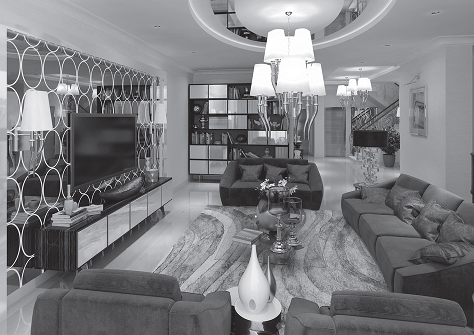

In [13]:
image_ko

In [25]:
sample = ["rug has been rolled up in the middle of a room.",
"cabinet drawer has been opened.",
"television is being set on the floor.",
"light fixture is hanging from the ceiling.",]


In [32]:
inputs = processor(text=sample, images=image_ko, return_tensors='pt', padding=True)

In [33]:
with torch.no_grad():
    outputs = model(**inputs)

In [34]:
for label, prob in zip(sample, outputs.logits_per_image.softmax(dim=-1)[0]):
    print(f"{label} - {prob}")

rug has been rolled up in the middle of a room. - 0.033053163439035416
cabinet drawer has been opened. - 0.002710231114178896
television is being set on the floor. - 0.025400906801223755
light fixture is hanging from the ceiling. - 0.9388357400894165


In [59]:
import os
import ssl

import pandas as pd
from urllib.request import urlretrieve
from bs4 import BeautifulSoup

ssl._create_default_https_context = ssl._create_unverified_context


In [9]:
target = './naver_news_images'
os.makedirs(target, exist_ok=True)

In [74]:
url = "https://news.naver.com/main/ranking/popularDay.naver?date={}"
bs = BeautifulSoup(requests.get(url.format('20260714')).text)


In [75]:
tmp = bs.find_all("a", {'class': "list_img nclicks('RBP.rnknws')"})

In [76]:
tmp

[<a aria-hidden="true" class="list_img nclicks('RBP.rnknws')" href="https://n.news.naver.com/article/009/0005707016?ntype=RANKING" tabindex="-1">
 <img alt="" height="70" onerror="this.src='https://ssl.pstatic.net/static.news/image/news/errorimage/noimage_70x70_1.png';" src="https://mimgnews.pstatic.net/image/origin/009/2026/07/14/5707016.jpg?type=nf70_70" width="70"/>
 </a>,
 <a aria-hidden="true" class="list_img nclicks('RBP.rnknws')" href="https://n.news.naver.com/article/009/0005706992?ntype=RANKING" tabindex="-1">
 <img alt="" height="70" onerror="this.src='https://ssl.pstatic.net/static.news/image/news/errorimage/noimage_70x70_1.png';" src="https://mimgnews.pstatic.net/image/origin/009/2026/07/13/5706992.jpg?type=nf70_70" width="70"/>
 </a>,
 <a aria-hidden="true" class="list_img nclicks('RBP.rnknws')" href="https://n.news.naver.com/article/009/0005707023?ntype=RANKING" tabindex="-1">
 <img alt="" height="70" onerror="this.src='https://ssl.pstatic.net/static.news/image/news/error

In [77]:
tmp[0].find("img")['src'].split("?")[0]

'https://mimgnews.pstatic.net/image/origin/009/2026/07/14/5707016.jpg'

In [79]:
from urllib import request

for x in tmp:
    try:
        myurl = x.find("img")['src'].split("?")[0]
        file_name = myurl.split("/")[-1]
        request.urlretrieve(myurl, f"{target}/{file_name}")
    except Exception as e:
        print(e)
        break


'src'


In [80]:
from datetime import date, datetime, timedelta

In [82]:
for i in range(5):
    target_date = (date.today() - timedelta(days=i)).strftime("%Y%m%d")
    url = "https://news.naver.com/main/ranking/popularDay.naver?date={}"
    bs = BeautifulSoup(requests.get(url.format(target_date)).text)
    tmp = bs.find_all("a", {'class': "list_img nclicks('RBP.rnknws')"})
    for x in tmp:
        try:
            myurl = x.find("img")['src'].split("?")[0]
            file_name = myurl.split("/")[-1]
            request.urlretrieve(myurl, f"{target}/{file_name}")
        except Exception as e:
            print(e)
            break

'src'
'src'
'src'
'src'
'src'


In [1]:
from chromadb.utils.embedding_functions import OpenCLIPEmbeddingFunction
from chromadb.utils.data_loaders import ImageLoader
import chromadb
from huggingface_hub import login

import os
from dotenv import load_dotenv
load_dotenv()

os.environ["HF_HUB_DISABLE_XET"] = "1"

hf_key = os.getenv("ORACLE_0713")
from huggingface_hub import login
login(token=hf_key)

In [3]:
chroma_client = chromadb.PersistentClient(path="./img_vecdb")
image_loader = ImageLoader()
CLIP = OpenCLIPEmbeddingFunction()
image_vdb =chroma_client.get_or_create_collection(
    name='news_image',
    embedding_function=CLIP,
    data_loader=image_loader
)


open_clip_model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

open_clip_model.safetensors: downloading bytes:           |  0.00B            

In [14]:
os.listdir(target)

['520920.jpg',
 '1178250.jpg',
 '1860498.jpg',
 '1371435.jpg',
 '5788035.jpg',
 '2379049.jpg',
 '12216801.jpg',
 '12216154.jpg',
 '1860665.jpg',
 '3660362.jpg',
 '12216182.jpg',
 '5788626.jpg',
 '16192487.jpg',
 '520909.jpg',
 '5385491.jpg',
 '5385485.jpg',
 '133566.jpg',
 '1372249.jpg',
 '6327204.jpg',
 '941559.jpg',
 '942078.jpg',
 '16188422.jpg',
 '500952.jpg',
 '1511199.jpg',
 '12216369.jpg',
 '3110423.jpg',
 '2379076.jpg',
 '5788585.jpg',
 '5385531.jpg',
 '2813326.jpg',
 '5384607.jpg',
 '5789498.jpg',
 '133559.jpg',
 '12216750.jpg',
 '1178905.jpg',
 '2379103.jpg',
 '2379113.jpg',
 '12217476.jpg',
 '133561.jpg',
 '1371221.jpg',
 '2668799.jpg',
 '4167345.jpg',
 '31909.jpg',
 '3457940.jpg',
 '190180.jpg',
 '5788594.jpg',
 '1510916.jpg',
 '2813487.jpg',
 '500573.jpg',
 '1371618.jpg',
 '113061.jpg',
 '113049.jpg',
 '12216379.jpg',
 '3457941.jpg',
 '500611.jpg',
 '16192324.jpg',
 '884173.jpg',
 '1371552.jpg',
 '16191822.jpg',
 '1371546.jpg',
 '16192481.jpg',
 '1860702.jpg',
 '2379138.jp

In [11]:
ids = []
uris = []
for i, file in enumerate(os.listdir(target)):
    file_path = os.path.join(target, file)
    ids.append(str(i))
    uris.append(file_path)

In [15]:
uris

['./naver_news_images/520920.jpg',
 './naver_news_images/1178250.jpg',
 './naver_news_images/1860498.jpg',
 './naver_news_images/1371435.jpg',
 './naver_news_images/5788035.jpg',
 './naver_news_images/2379049.jpg',
 './naver_news_images/12216801.jpg',
 './naver_news_images/12216154.jpg',
 './naver_news_images/1860665.jpg',
 './naver_news_images/3660362.jpg',
 './naver_news_images/12216182.jpg',
 './naver_news_images/5788626.jpg',
 './naver_news_images/16192487.jpg',
 './naver_news_images/520909.jpg',
 './naver_news_images/5385491.jpg',
 './naver_news_images/5385485.jpg',
 './naver_news_images/133566.jpg',
 './naver_news_images/1372249.jpg',
 './naver_news_images/6327204.jpg',
 './naver_news_images/941559.jpg',
 './naver_news_images/942078.jpg',
 './naver_news_images/16188422.jpg',
 './naver_news_images/500952.jpg',
 './naver_news_images/1511199.jpg',
 './naver_news_images/12216369.jpg',
 './naver_news_images/3110423.jpg',
 './naver_news_images/2379076.jpg',
 './naver_news_images/578858

In [13]:
image_vdb.add(ids=ids, uris=uris)

In [32]:
result = image_vdb.query(
    query_texts=['손승운'],
    n_results=5,
    include=['uris', 'distances']
)

In [33]:
result

{'ids': [['142', '98', '336', '64', '276']],
 'embeddings': None,
 'documents': None,
 'uris': [['./naver_news_images/5385581.jpg',
   './naver_news_images/3110442.jpg',
   './naver_news_images/2379130.jpg',
   './naver_news_images/112779.jpg',
   './naver_news_images/1178933.jpg']],
 'included': ['uris', 'distances'],
 'data': None,
 'metadatas': None,
 'distances': [[0.6670681238174438,
   0.6811511516571045,
   0.6884000301361084,
   0.6901959180831909,
   0.6912864446640015]]}

In [ ]:
for image in result['uris'][0]:
    Image.open(image).show()